# ECON4002 — Week 6: Consumer Theory II: Duality & Welfare R Code

**University of Western Australia**  
*R implementations for indirect utility, expenditure functions, Slutsky decomposition, and welfare measures*

---

## Key Formulae

Expenditure minimisation: $\min p_1 x_1 + p_2 x_2$ s.t. $U(x_1,x_2) \geq \bar{U}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 6 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 6: Consumer Theory II: Duality & Welfare R Code — ready!\n')

Week 6: Consumer Theory II: Duality & Welfare R Code — ready!


## Indirect Utility

### W6-CS01 — Indirect Utility Function

> **Note:** v(p,m) = k·m/(p₁^α p₂^(1-α)) where k = α^α(1-α)^(1-α)

In [ ]:
# Cobb-Douglas indirect utility
indirect_utility_CD <- function(p1, p2, m, alpha = 0.5) {
  k <- alpha^alpha * (1-alpha)^(1-alpha)
  v <- k * m / (p1^alpha * p2^(1-alpha))
  return(v)
}

# Test
v <- indirect_utility_CD(p1 = 2, p2 = 3, m = 120, alpha = 0.4)
cat('Indirect utility:', round(v, 3))

### W6-CS02 — Roy's Identity Verification

> **Note:** Roy's Identity: xᵢᵐ = -(∂v/∂pᵢ)/(∂v/∂m)

In [ ]:
# Verify Roy's Identity numerically
roys_identity <- function(v_fn, p1, p2, m, h = 1e-6) {
  # Numerical partial derivatives
  dv_dp1 <- (v_fn(p1 + h, p2, m) - v_fn(p1 - h, p2, m)) / (2 * h)
  dv_dp2 <- (v_fn(p1, p2 + h, m) - v_fn(p1, p2 - h, m)) / (2 * h)
  dv_dm <- (v_fn(p1, p2, m + h) - v_fn(p1, p2, m - h)) / (2 * h)
  
  x1 <- -dv_dp1 / dv_dm
  x2 <- -dv_dp2 / dv_dm
  return(c(x1 = x1, x2 = x2))
}

# Compare with direct calculation
p1 <- 2; p2 <- 3; m <- 120; alpha <- 0.4
x_roy <- roys_identity(function(p1, p2, m) indirect_utility_CD(p1, p2, m, alpha), 
                        p1, p2, m)
x_direct <- c(x1 = alpha * m / p1, x2 = (1-alpha) * m / p2)

cat('From Roy:', round(x_roy, 3), '\n')
cat('Direct:', round(x_direct, 3))

## Expenditure

### W6-CS03 — Expenditure Function

> **Note:** e(p,ū) = (ū/k)·p₁^α p₂^(1-α). Inverse of indirect utility.

In [ ]:
# Cobb-Douglas expenditure function
expenditure_CD <- function(p1, p2, u, alpha = 0.5) {
  k <- alpha^alpha * (1-alpha)^(1-alpha)
  e <- u / k * p1^alpha * p2^(1-alpha)
  return(e)
}

# Test: What does it cost to achieve u=20 at p1=2, p2=3?
e <- expenditure_CD(p1 = 2, p2 = 3, u = 20, alpha = 0.5)
cat('Minimum expenditure:', round(e, 2))

### W6-CS04 — Verify Duality: v and e are Inverses

> **Note:** v and e are inverses with respect to their second arguments.

In [ ]:
# Verify: v(p, e(p,u)) = u and e(p, v(p,m)) = m
alpha <- 0.5
p1 <- 2; p2 <- 3; m <- 100; u <- 15

# Test 1: v(p, e(p,u)) = u
e_val <- expenditure_CD(p1, p2, u, alpha)
v_of_e <- indirect_utility_CD(p1, p2, e_val, alpha)
cat('u =', u, ', v(p, e(p,u)) =', round(v_of_e, 4), '\n')

# Test 2: e(p, v(p,m)) = m
v_val <- indirect_utility_CD(p1, p2, m, alpha)
e_of_v <- expenditure_CD(p1, p2, v_val, alpha)
cat('m =', m, ', e(p, v(p,m)) =', round(e_of_v, 4))

## Hicksian

### W6-CS05 — Hicksian Demand Functions

> **Note:** Hicksian demand holds utility constant (compensated demand).

In [ ]:
# Cobb-Douglas Hicksian demand
hicksian_CD <- function(p1, p2, u, alpha = 0.5) {
  x1_h <- u * (alpha * p2 / ((1-alpha) * p1))^(1-alpha)
  x2_h <- u * ((1-alpha) * p1 / (alpha * p2))^alpha
  return(c(x1 = x1_h, x2 = x2_h))
}

# Test
x_h <- hicksian_CD(p1 = 2, p2 = 3, u = 20, alpha = 0.5)
cat('Hicksian demands at u=20:', round(x_h, 3))

### W6-CS06 — Shephard's Lemma Verification

> **Note:** Shephard's Lemma: derivative of e w.r.t. price = Hicksian demand.

In [ ]:
# Verify Shephard's Lemma: x^h_i = ∂e/∂p_i
shephards_lemma <- function(e_fn, p1, p2, u, h = 1e-6) {
  de_dp1 <- (e_fn(p1 + h, p2, u) - e_fn(p1 - h, p2, u)) / (2 * h)
  de_dp2 <- (e_fn(p1, p2 + h, u) - e_fn(p1, p2 - h, u)) / (2 * h)
  return(c(x1 = de_dp1, x2 = de_dp2))
}

# Compare
alpha <- 0.5; p1 <- 2; p2 <- 3; u <- 20
x_shephard <- shephards_lemma(
  function(p1, p2, u) expenditure_CD(p1, p2, u, alpha), p1, p2, u)
x_hicksian <- hicksian_CD(p1, p2, u, alpha)

cat('From Shephard:', round(x_shephard, 3), '\n')
cat('Hicksian:', round(x_hicksian, 3))

## Slutsky

### W6-CS07 — Slutsky Decomposition

> **Note:** Total = Substitution + Income. Substitution always ≤ 0 for own-price.

In [ ]:
slutsky_decomposition <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  # Original demands and utility
  x_old <- c(alpha * m / p1_old, (1-alpha) * m / p2)
  u_old <- indirect_utility_CD(p1_old, p2, m, alpha)
  
  # New Marshallian demands
  x_new <- c(alpha * m / p1_new, (1-alpha) * m / p2)
  
  # Hicksian at new prices, old utility
  x_hicks <- hicksian_CD(p1_new, p2, u_old, alpha)
  
  # Decomposition for x1
  total <- x_new[1] - x_old[1]
  substitution <- x_hicks[1] - x_old[1]
  income <- total - substitution
  
  cat('=== Slutsky Decomposition ===\n')
  cat('Price change: p1 from', p1_old, 'to', p1_new, '\n\n')
  cat('Original x1:', round(x_old[1], 3), '\n')
  cat('New x1:', round(x_new[1], 3), '\n')
  cat('Hicksian x1:', round(x_hicks[1], 3), '\n\n')
  cat('Total effect:', round(total, 3), '\n')
  cat('Substitution effect:', round(substitution, 3), '\n')
  cat('Income effect:', round(income, 3), '\n')
  cat('Check (S + I = T):', round(substitution + income, 3), '\n')
  
  return(list(total = total, substitution = substitution, income = income))
}

# Example: p1 increases from 2 to 4
slutsky_decomposition(p1_old = 2, p1_new = 4, p2 = 2, m = 100, alpha = 0.5)

### W6-CS08 — Visualize Slutsky Decomposition

> **Note:** A→B: substitution (along IC). B→C: income (between ICs).

In [ ]:
plot_slutsky <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  # Calculate all points
  x_A <- c(alpha * m / p1_old, (1-alpha) * m / p2)  # Original
  u_old <- indirect_utility_CD(p1_old, p2, m, alpha)
  x_C <- c(alpha * m / p1_new, (1-alpha) * m / p2)  # New
  x_B <- hicksian_CD(p1_new, p2, u_old, alpha)       # Compensated
  
  # Plot setup
  x1_max <- max(x_A[1], x_B[1], x_C[1]) * 1.3
  x2_max <- max(x_A[2], x_B[2], x_C[2]) * 1.3
  
  plot(NULL, xlim = c(0, x1_max), ylim = c(0, x2_max),
       xlab = expression(x[1]), ylab = expression(x[2]),
       main = 'Slutsky Decomposition')
  
  # Budget lines
  abline(a = m/p2, b = -p1_old/p2, col = 'blue', lwd = 2)   # Original
  abline(a = m/p2, b = -p1_new/p2, col = 'red', lwd = 2)    # New
  # Compensated budget (through B with new slope)
  comp_income <- expenditure_CD(p1_new, p2, u_old, alpha)
  abline(a = comp_income/p2, b = -p1_new/p2, col = 'orange', lwd = 2, lty = 2)
  
  # Indifference curves
  x1_seq <- seq(0.1, x1_max, length = 200)
  for (u in c(u_old, indirect_utility_CD(p1_new, p2, m, alpha))) {
    x2_seq <- (u / x1_seq^alpha)^(1/(1-alpha))
    x2_seq[x2_seq > x2_max] <- NA
    lines(x1_seq, x2_seq, col = 'gray', lwd = 1)
  }
  
  # Points
  points(x_A[1], x_A[2], pch = 19, cex = 1.5, col = 'blue')
  points(x_B[1], x_B[2], pch = 19, cex = 1.5, col = 'orange')
  points(x_C[1], x_C[2], pch = 19, cex = 1.5, col = 'red')
  
  text(x_A[1], x_A[2], 'A', pos = 4)
  text(x_B[1], x_B[2], 'B', pos = 4)
  text(x_C[1], x_C[2], 'C', pos = 4)
  
  legend('topright', c('Original budget', 'New budget', 'Compensated', 'A: Original', 'B: Substitution', 'C: Final'),
         col = c('blue', 'red', 'orange', 'blue', 'orange', 'red'),
         lty = c(1, 1, 2, NA, NA, NA), pch = c(NA, NA, NA, 19, 19, 19))
  grid()
}

plot_slutsky(p1_old = 2, p1_new = 4, p2 = 2, m = 100, alpha = 0.5)

## Welfare

### W6-CS09 — Compensating Variation

> **Note:** CV uses OLD utility as reference, NEW prices for evaluation.

In [ ]:
# CV = e(p_new, u_old) - m
# Income needed to compensate for price change

compensating_variation <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  u_old <- indirect_utility_CD(p1_old, p2, m, alpha)
  e_new <- expenditure_CD(p1_new, p2, u_old, alpha)
  CV <- e_new - m
  return(CV)
}

# Example: p1 rises from 2 to 4
CV <- compensating_variation(p1_old = 2, p1_new = 4, p2 = 2, m = 100, alpha = 0.5)
cat('CV:', round(CV, 2), '\n')
cat('Interpretation: Consumer needs $', round(CV, 2), ' extra to maintain original utility')

### W6-CS10 — Equivalent Variation

> **Note:** EV uses NEW utility as reference, OLD prices for evaluation.

In [ ]:
# EV = m - e(p_old, u_new)
# Income change at old prices equivalent to price change

equivalent_variation <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  u_new <- indirect_utility_CD(p1_new, p2, m, alpha)
  e_old <- expenditure_CD(p1_old, p2, u_new, alpha)
  EV <- m - e_old
  return(EV)
}

# Example
EV <- equivalent_variation(p1_old = 2, p1_new = 4, p2 = 2, m = 100, alpha = 0.5)
cat('EV:', round(EV, 2), '\n')
cat('Interpretation: Losing $', round(EV, 2), ' at old prices would be equivalent')

### W6-CS11 — Complete Welfare Analysis

> **Note:** For price increases: CV > ΔCS > EV (different reference utilities).

In [ ]:
welfare_analysis <- function(p1_old, p1_new, p2, m, alpha = 0.5) {
  # Utilities
  u_old <- indirect_utility_CD(p1_old, p2, m, alpha)
  u_new <- indirect_utility_CD(p1_new, p2, m, alpha)
  
  # Welfare measures
  CV <- compensating_variation(p1_old, p1_new, p2, m, alpha)
  EV <- equivalent_variation(p1_old, p1_new, p2, m, alpha)
  
  # Consumer surplus change (approximation using Marshallian demand)
  # For Cobb-Douglas: CS = α·m·ln(p_old/p_new) approximately
  delta_CS_approx <- alpha * m * log(p1_old / p1_new)
  
  cat('=== Welfare Analysis ===\n')
  cat('Price change: p1 from', p1_old, 'to', p1_new, '\n\n')
  cat('Old utility:', round(u_old, 3), '\n')
  cat('New utility:', round(u_new, 3), '\n')
  cat('Utility change:', round(u_new - u_old, 3), '\n\n')
  cat('CV:', round(CV, 2), '\n')
  cat('EV:', round(EV, 2), '\n')
  cat('ΔCS (approx):', round(delta_CS_approx, 2), '\n\n')
  
  if (p1_new > p1_old) {
    cat('Price increase: CV > EV (consumer worse off)\n')
  } else {
    cat('Price decrease: EV > CV (consumer better off)\n')
  }
  
  return(list(u_old = u_old, u_new = u_new, CV = CV, EV = EV))
}

welfare_analysis(p1_old = 2, p1_new = 4, p2 = 2, m = 100, alpha = 0.5)

## Complete

### W6-CS12 — Complete Duality Toolkit

> **Note:** Comprehensive toolkit for all duality-related computations.

In [ ]:
# All consumer duality functions in one object
CD_duality <- function(alpha = 0.5) {
  k <- alpha^alpha * (1-alpha)^(1-alpha)
  
  list(
    # Indirect utility function
    v = function(p1, p2, m) k * m / (p1^alpha * p2^(1-alpha)),
    
    # Expenditure function
    e = function(p1, p2, u) u / k * p1^alpha * p2^(1-alpha),
    
    # Marshallian demand
    x_m = function(p1, p2, m) {
      c(x1 = alpha * m / p1, x2 = (1-alpha) * m / p2)
    },
    
    # Hicksian demand
    x_h = function(p1, p2, u) {
      c(x1 = u * (alpha * p2 / ((1-alpha) * p1))^(1-alpha),
        x2 = u * ((1-alpha) * p1 / (alpha * p2))^alpha)
    },
    
    # CV and EV
    CV = function(p1_old, p1_new, p2, m) {
      u_old <- k * m / (p1_old^alpha * p2^(1-alpha))
      e_new <- u_old / k * p1_new^alpha * p2^(1-alpha)
      e_new - m
    },
    
    EV = function(p1_old, p1_new, p2, m) {
      u_new <- k * m / (p1_new^alpha * p2^(1-alpha))
      e_old <- u_new / k * p1_old^alpha * p2^(1-alpha)
      m - e_old
    }
  )
}

# Usage
fns <- CD_duality(alpha = 0.4)
cat('v(2,3,120) =', fns$v(2, 3, 120), '\n')
cat('e(2,3,25) =', fns$e(2, 3, 25), '\n')
cat('x_m(2,3,120) =', fns$x_m(2, 3, 120), '\n')
cat('CV for p1: 2→4 =', fns$CV(2, 4, 3, 120))

## Demand Curves

### W6-CS13 — Plot Marshallian vs Hicksian Demand

> **Note:** Hicksian steeper (no income effect). They cross at reference point.

In [ ]:
plot_marshallian_hicksian <- function(p2, m, u_ref, alpha = 0.5) {
  p1_range <- seq(0.5, 10, by = 0.1)
  
  # Marshallian demand (holds income constant)
  x1_marshallian <- alpha * m / p1_range
  
  # Hicksian demand (holds utility constant)
  x1_hicksian <- u_ref * (alpha * p2 / ((1-alpha) * p1_range))^(1-alpha)
  
  plot(x1_marshallian, p1_range, type = 'l', col = 'blue', lwd = 2,
       xlab = expression(x[1]), ylab = expression(p[1]),
       main = 'Marshallian vs Hicksian Demand',
       xlim = c(0, max(x1_marshallian) * 1.1))
  lines(x1_hicksian, p1_range, col = 'red', lwd = 2, lty = 2)
  
  legend('topright', c('Marshallian (income const)', 'Hicksian (utility const)'),
         col = c('blue', 'red'), lty = c(1, 2), lwd = 2)
  grid()
}

# Reference utility at p1=2
u_ref <- indirect_utility_CD(2, 3, 120, 0.5)
plot_marshallian_hicksian(p2 = 3, m = 120, u_ref = u_ref, alpha = 0.5)

## Numerical

### W6-CS14 — Numerical Expenditure Minimization

> **Note:** Numerical solver for any utility function (not just Cobb-Douglas).

In [ ]:
library(nloptr)

expenditure_min_numerical <- function(U_fn, p1, p2, u_target) {
  # Objective: minimize p1*x1 + p2*x2
  eval_f <- function(x) p1 * x[1] + p2 * x[2]
  eval_grad_f <- function(x) c(p1, p2)
  
  # Constraint: U(x) >= u_target → U(x) - u_target >= 0
  eval_g_ineq <- function(x) u_target - U_fn(x[1], x[2])
  eval_jac_g_ineq <- function(x) {
    h <- 1e-6
    c(-(U_fn(x[1]+h, x[2]) - U_fn(x[1]-h, x[2]))/(2*h),
      -(U_fn(x[1], x[2]+h) - U_fn(x[1], x[2]-h))/(2*h))
  }
  
  result <- nloptr(
    x0 = c(u_target, u_target),
    eval_f = eval_f,
    eval_grad_f = eval_grad_f,
    eval_g_ineq = eval_g_ineq,
    eval_jac_g_ineq = eval_jac_g_ineq,
    lb = c(0.001, 0.001),
    opts = list(algorithm = 'NLOPT_LD_MMA', xtol_rel = 1e-8)
  )
  
  return(list(x_h = result$solution, expenditure = result$objective))
}

# Test with Cobb-Douglas
U_CD <- function(x1, x2) x1^0.5 * x2^0.5
result <- expenditure_min_numerical(U_CD, p1 = 2, p2 = 3, u_target = 20)
cat('Hicksian demands:', round(result$x_h, 3), '\n')
cat('Min expenditure:', round(result$expenditure, 2))

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

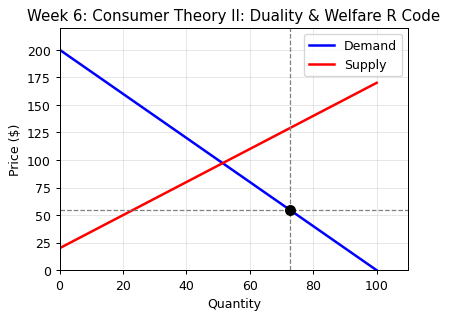

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Duality Functions**

```r
v = function(p1, p2, m) {...}
e = function(p1, p2, u) {...}
# Verify: v(p, e(p,u)) = u
```

**Slutsky Decomposition**

```r
total = x_new - x_old
substitution = x_hicksian - x_old
income = total - substitution
```

**Welfare Measures**

```r
CV = e(p_new, u_old) - m
EV = m - e(p_old, u_new)
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `CV and EV have wrong signs` | Confused which utility/prices to use | CV: old utility, new prices. EV: new utility, old prices. |
| `Slutsky doesn't sum correctly` | Wrong formula or sign error | Total = Substitution + Income. Check reference utility for Hicksian. |
| `v and e not inverse` | Formula error in one function | Must have v(p, e(p,u)) = u and e(p, v(p,m)) = m exactly. |